# Preprocesamiento de Datos: Marco temporal Horario (1h)

Este notebook contiene el pipeline de ingeniería de datos para el marco temporal Intradiario (Hourly). El objetivo es transformar los datos brutos de precios de cierre en un espacio de estados ($s_t$) optimizado para el entrenamiento de modelos de State Representation Learning (SRL) y agentes de Deep Reinforcement Learning (DRL).

## Librerías

Se utilizan librerías estándar para manipulación de datos (Pandas, NumPy), herramientas de interpolación matemática (SciPy) y la implementación personalizada de la Transformada Wavelet Discreta (MODWT) para el filtrado de ruido.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from scipy.interpolate import CubicSpline

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler

import sys
sys.path.append('../')

from src.modwt import *

import pywt
from pywt import wavedec
from pywt import Wavelet

Se definen los rangos temporales para asegurar la consistencia entre los marcos de 1h y 1d. El periodo de estudio abarca desde finales de 2021 hasta mediados de 2025, cubriendo diversos ciclos de mercado para mejorar la robustez del modelo.

In [2]:
ref_data_range = "1H"
#from_date = '2021-12-31 00:00:00' # 2020-12-31 00:00:00 para btc y spy
from_date = '2022-04-02 00:00:00' # 2020-12-31 00:00:00

until_date = '2025-07-31 00:00:00'
until_date_2 = '2025-08-01 00:00:00'

In [3]:
# list_data_name = ["BTCUSDT_1h", "ETHUSDT_1h", "BNBUSDT_1h", "XRPUSDT_1h", "ADAUSDT_1h", "LTCUSDT_1h"]

MODE = 2

if MODE == 1:
    list_data_name = ["BTCUSDT_1h"] #para bitcoin
    foldername = "BTC"
    TRAIN_END_DATE = '2024-12-31'

elif MODE == 2:
    list_data_name = ["ETHUSDT_1h"] #para ethereum
    foldername = "ETH"
    TRAIN_END_DATE = '2025-05-11'

elif MODE == 3:
    list_data_name = ["SPY_1h"] # para spy
    foldername = "SP500"
    TRAIN_END_DATE = '2025-04-10'

#TRAIN_END_DATE = '2025-05-11' #para ethereum
#TRAIN_END_DATE = '2024-12-31' #para bitcoin
#TRAIN_END_DATE = '2025-04-10' # para spy

Para el criptoactivo (BTCUSDT) se ejecutan los siguientes pasos críticos:

1. Sincronización de Calendario: Reindexación para detectar huecos temporales y asegurar una serie continua.

2. Interpolación por Splines Cúbicos: Relleno de datos faltantes preservando la estructura geométrica de la señal, a diferencia de los métodos lineales simples.

3. Estacionariedad (Log-Returns): Conversión de precios nominales a retornos logarítmicos para estabilizar la media y varianza.

4. Normalización Adaptativa: Tratamiento de outliers mediante cuantiles (2%-98%) y escalado Min-Max al rango [-1, 1].

5. Análisis Multiresolución (MODWT): Descomposición de la señal mediante Wavelets para separar la tendencia estructural del ruido transaccional de alta frecuencia.

In [4]:
for data_name in list_data_name:
    # 1. Importación y Preparación Inicial
    ccy = data_name.split('_')[0]
    data = pd.read_csv(f'../data/{foldername}/{data_name}_data_from_20210101_to_20251031.csv')
    
    
    data['date'] = pd.to_datetime(data['date'], format='ISO8601').dt.floor('h')
    
    data.set_index('date', inplace=True)
    data = data[~data.index.duplicated(keep='first')] # Se quitan duplicados por si acaso
    data.sort_index(inplace=True)

    print(f"--- Procesando {data_name} ---")
    
    # 2. Recorte temporal 
    start_ts = pd.to_datetime(from_date)
    end_ts = pd.to_datetime(until_date_2)
    data = data.loc[start_ts : end_ts]
    print(f"Filas tras recorte inicial: {len(data)}")

    # 3. Sincronización del calendario (Rellenado de huecos)
    
    my_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='h')
    
    # Esto rellena los huecos del tiempo automáticamente
    data = data.reindex(my_range)
    print(f"Filas tras sincronizar calendario: {len(data)}")

    # 4. Interpolación Cubic Spline
    data_interp_temp = data.copy()
    data_interp_temp.reset_index(inplace=True)
    data_interp_temp.rename(columns={'index': 'date'}, inplace=True)
    
    data_interp_temp['date_ordinal'] = data_interp_temp['date'].apply(lambda x: x.timestamp())

    # Solo interpolamos si tenemos datos
    known_data = data_interp_temp.dropna(subset=['close'])
    if len(known_data) > 1:
        cs = CubicSpline(known_data['date_ordinal'], known_data['close'])
        missing_idx = data_interp_temp[data_interp_temp['close'].isnull()].index
        if not missing_idx.empty:
            data_interp_temp.loc[missing_idx, 'close'] = cs(data_interp_temp.loc[missing_idx, 'date_ordinal'])
    
    data_interp_temp.set_index('date', inplace=True)
    data = data_interp_temp.copy()

    # 5. Log Returns y Limpieza de NaNs
    data['processed_log_return'] = np.log(data['close'] / data['close'].shift(1))
    
    data.dropna(subset=['processed_log_return'], inplace=True)
    print(f"Filas listas para normalizar: {len(data)}")

    # 6. Outliers y Normalización (PROTECCIÓN ANTI-LEAKAGE)
    if len(data) > 0:
        # A. Calculamos límites de outliers usando SOLO el set de entrenamiento
        # (Esto es seguro porque solo estamos extrayendo dos números: el cuantil 0.02 y 0.98)
        upper = data.loc[:TRAIN_END_DATE, 'processed_log_return'].quantile(0.98)
        lower = data.loc[:TRAIN_END_DATE, 'processed_log_return'].quantile(0.02)
        
        # B. Aplicamos el clip a TODO el dataset (Creamos la columna que faltaba)
        data['outliers_processed_log_return'] = data['processed_log_return'].clip(lower=lower, upper=upper)
        
        # C. Ahora que la columna EXISTE, separamos para el Scaler
        data_train_subset = data.loc[:TRAIN_END_DATE]
        
        if data_train_subset.empty:
            print(f"ERROR: No hay datos antes de {TRAIN_END_DATE}.")
        else:
            # D. Ajustamos el Scaler SOLO con el set de entrenamiento (la columna ya existe)
            scaler = MinMaxScaler(feature_range=(-1, 1))
            scaler.fit(data_train_subset[['outliers_processed_log_return']])
            
            # E. Transformamos TODO el dataset
            data[['normalized_outliers_processed_log_return']] = scaler.transform(data[['outliers_processed_log_return']])
            
            print(f"--- Parámetros fijados con datos hasta {TRAIN_END_DATE} ---")
            print(f"Límites Outliers: [{lower:.6f}, {upper:.6f}]")
    else:
        print("ERROR: La tabla sigue vacía.")
    # 7. ELIMINACIÓN DE MODWT (Para evitar Data Leakage)
    # En lugar de usar Wavelets no causales, usaremos la señal de retornos limpia de outliers
    # Esto asegura que el modelo aprenda de datos reales y ruidosos.
    
    # Creamos una copia clara para el entrenamiento de SRL
    # El State Space se basará en el log-return normalizado
    data['srl_input'] = data['normalized_outliers_processed_log_return']

    # 8. Guardado Final Limpio (sin ":")
    from_safe = from_date.replace(":", "-").replace(" ", "_")
    until_safe = until_date.replace(":", "-").replace(" ", "_")
    
    # Eliminación de valores nulos (importante tras el shift inicial del log-return)
    data.dropna(inplace=True)
    
    # --- VERIFICACIÓN DE SEGURIDAD ---
    # Eliminamos cualquier rastro de columnas 'wtmra' si existieran de ejecuciones previas
    cols_to_drop = [c for c in data.columns if 'wtmra' in c]
    data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    print(f"¿Quedan nulos antes de guardar?: {data.isnull().values.any()}")
    print(f"Filas finales enviadas al CSV: {len(data)}")

    output_file = f'../data/{foldername}/01-output-{ccy}_1h-from-{from_safe}-until-{until_safe}-log-return.csv'
    data.to_csv(output_file)
    print(f"Archivo guardado en: {output_file}")

C:\Users\javil\AppData\Local\Temp\ipykernel_13076\4115392421.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(f'../data/{foldername}/{data_name}_data_from_20210101_to_20251031.csv')


--- Procesando ETHUSDT_1h ---
Filas tras recorte inicial: 29209
Filas tras sincronizar calendario: 29209
Filas listas para normalizar: 29208
--- Parámetros fijados con datos hasta 2025-05-11 ---
Límites Outliers: [-0.016901, 0.016439]
¿Quedan nulos antes de guardar?: False
Filas finales enviadas al CSV: 29208
Archivo guardado en: ../data/ETH/01-output-ETHUSDT_1h-from-2022-04-02_00-00-00-until-2025-07-31_00-00-00-log-return.csv


Una vez procesada la serie, se verifica que la señal sea estacionaria y que esté correctamente acotada en el rango de activación del modelo. Las siguientes gráficas contrastan el precio bruto frente a la representación final de entrada (Log-Return Normalizado con Denoising).

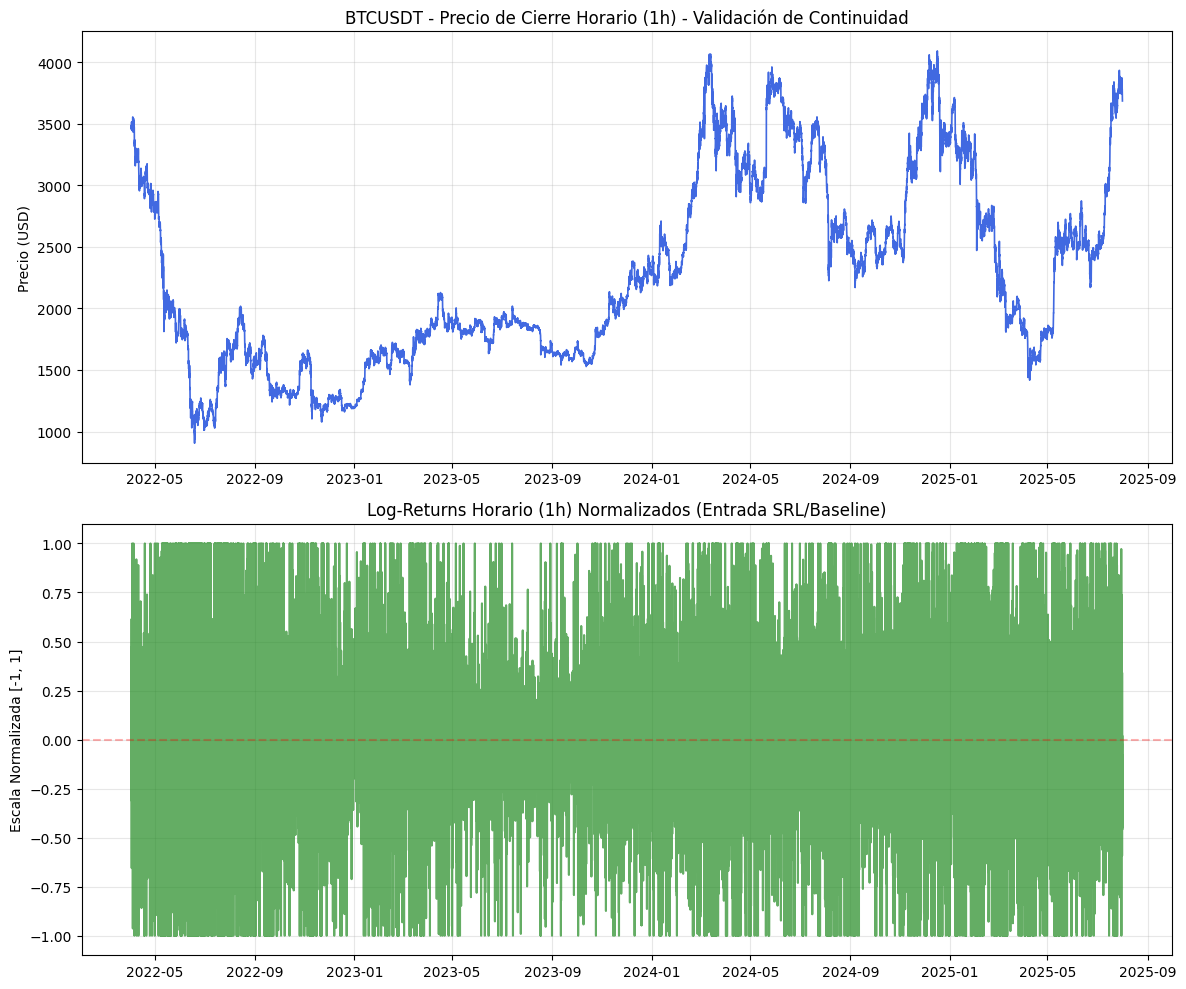

 DIAGNÓSTICO DE INTEGRIDAD: MARCO HORARIO (1H)
- Rango temporal:      2022-04-02 01:00:00 a 2025-08-01 00:00:00
- Total observaciones: 29208
- ¿Existen nulos?:     False
- Media de retornos:   0.015225
- Valor Máximo:        1.0000
- Valor Mínimo:        -1.0000


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carga estandarizada del dataframe
check_df = pd.read_csv(output_file, index_col=0, parse_dates=True)

# Detectamos el timeframe dinámicamente para los títulos
tf_label = "Horario (1h)" if "1h" in output_file.lower() else "Diario (1d)"

# 2. Configuración visual
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica 1: Continuidad del Precio (Precio de Cierre)
column_price = 'close' if 'close' in check_df.columns else 'processed_close'
ax[0].plot(check_df[column_price], color='royalblue', linewidth=1.2)
ax[0].set_title(f'BTCUSDT - Precio de Cierre {tf_label} - Validación de Continuidad')
ax[0].set_ylabel('Precio (USD)')
ax[0].grid(True, alpha=0.3)

# Gráfica 2: Representación del Espacio de Estados (Log-Returns)
ax[1].plot(check_df['normalized_outliers_processed_log_return'], color='forestgreen', alpha=0.7)
ax[1].set_title(f'Log-Returns {tf_label} Normalizados (Entrada SRL/Baseline)')
ax[1].set_ylabel('Escala Normalizada [-1, 1]')
ax[1].axhline(y=0, color='red', linestyle='--', alpha=0.3) # Línea base de estacionariedad
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Bloque de Estadísticas Unificado para la Memoria del TFG
print(f"{'='*50}")
print(f" DIAGNÓSTICO DE INTEGRIDAD: MARCO {tf_label.upper()}")
print(f"{'='*50}")
print(f"- Rango temporal:      {check_df.index.min()} a {check_df.index.max()}")
print(f"- Total observaciones: {len(check_df)}")
print(f"- ¿Existen nulos?:     {check_df.isnull().values.any()}")
print(f"- Media de retornos:   {check_df['normalized_outliers_processed_log_return'].mean():.6f}")
print(f"- Valor Máximo:        {check_df['normalized_outliers_processed_log_return'].max():.4f}")
print(f"- Valor Mínimo:        {check_df['normalized_outliers_processed_log_return'].min():.4f}")
print(f"{'='*50}")

El archivo generado está libre de valores nulos y listo para ser utilizado. Este archivo constituye la base sólida para las siguientes fases del proyecto: la generación del Baseline mediante indicadores técnicos tradicionales (Features manuales) y el entrenamiento de modelos de State Representation Learning (SRL) para la obtención de embeddings latentes.